# ⚡ Solar Power Generation — Regression Analysis

This notebook performs a **complete end-to-end regression analysis** on a Solar Generation dataset.

**Target variable:** `AC Power in Watts`

The objective is to build, evaluate, and compare **10 regression algorithms**, tune the best performers with cross-validated hyperparameter search, and present interpretable visualisations of model behaviour.

---

**Table of Contents**

| # | Section | Rubric |
|---|---------|--------|
| 1 | Import Libraries | — |
| 2 | Dataset Loading & Structural Audit | A1 |
| 3 | Exploratory Data Analysis & Visualisations | A2, A3 |
| 4 | Data Cleaning | B1 |
| 5 | Feature Engineering | B3 |
| 6 | Encoding, Scaling & Train/Test Split | B2 |
| 7 | Model Training — 10 Regression Algorithms | C1 |
| 8 | Comparative Evaluation — Summary Table | C2 |
| 9 | Hyperparameter Tuning — Top 2 Models | C3 |
| 10 | Model Visualisations | C4 |
| 11 | Conclusion | — |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              ExtraTreesRegressor)

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Plotting defaults — colourblind-friendly palette as recommended
sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Dataset Loading & Structural Audit *(Rubric A1)*

Load the dataset and inspect its structure: shape, data types, missing-value counts, duplicates, and descriptive statistics of the target variable.

In [2]:
# Load dataset using a relative path (portable for GitHub clones)
df = pd.read_csv("solar_generation.csv")

# Clean column names (strip leading/trailing whitespace)
df.columns = df.columns.str.strip()

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

Dataset Shape: 118,865 rows × 9 columns

Column Names:
  1. MODULE_TEMP
  2. Amb_Temp
  3. WIND_Speed
  4. IRR (W/m2)
  5. DC Current in Amps
  6. AC Ir in Amps
  7. AC Iy in Amps
  8. AC Ib in Amps
  9. AC Power in Watts


In [3]:
print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

print(f"\n{'=' * 60}")
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

print(f"\n{'=' * 60}")
print("DUPLICATE ROWS")
print("=" * 60)
print(f"Duplicate rows: {df.duplicated().sum()}")

DATA TYPES
MODULE_TEMP           float64
Amb_Temp              float64
WIND_Speed            float64
IRR (W/m2)            float64
DC Current in Amps    float64
AC Ir in Amps         float64
AC Iy in Amps         float64
AC Ib in Amps         float64
AC Power in Watts       int64
dtype: object

MISSING VALUES
MODULE_TEMP           0
Amb_Temp              0
WIND_Speed            0
IRR (W/m2)            0
DC Current in Amps    0
AC Ir in Amps         0
AC Iy in Amps         0
AC Ib in Amps         0
AC Power in Watts     0
dtype: int64

Total missing cells: 0

DUPLICATE ROWS
Duplicate rows: 0


In [4]:
# Descriptive statistics for all columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MODULE_TEMP,118865.0,37.141972,12.017936,8.855000,26.69750,36.45750,46.67500,72.447500
Amb_Temp,118865.0,22.961983,3.921594,10.413610,20.08339,23.05870,26.03402,34.959970
WIND_Speed,118865.0,224.429052,230.238430,0.238025,28.32501,59.03028,442.72710,597.443500
IRR (W/m2),118865.0,428.093276,313.280827,2.129417,155.44750,357.74210,687.80180,1494.851000
DC Current in Amps,118865.0,355.902071,264.863384,0.600000,126.18000,298.60000,576.32000,995.679988
AC Ir in Amps,118865.0,172.329754,120.507508,1.400000,65.60000,150.00000,277.70000,461.200000
AC Iy in Amps,118865.0,172.190557,120.448101,1.400000,65.50000,150.00000,277.40000,461.100000
AC Ib in Amps,118865.0,172.351243,120.503308,1.500000,65.60000,150.10000,277.60000,461.700000
AC Power in Watts,118865.0,128081.179666,91193.677193,394.000000,47737.00000,110673.00000,206594.00000,332614.000000


In [5]:
# Target variable deep-dive
target = df['AC Power in Watts']
print("=" * 60)
print("TARGET VARIABLE ANALYSIS: AC Power in Watts")
print("=" * 60)
print(f"  Mean:     {target.mean():>12,.2f} W")
print(f"  Median:   {target.median():>12,.2f} W")
print(f"  Std Dev:  {target.std():>12,.2f} W")
print(f"  Skewness: {target.skew():>12.4f}")
print(f"  Kurtosis: {target.kurtosis():>12.4f}")
print(f"  Min:      {target.min():>12,} W")
print(f"  Max:      {target.max():>12,} W")

TARGET VARIABLE ANALYSIS: AC Power in Watts
  Mean:       128,081.18 W
  Median:     110,673.00 W
  Std Dev:     91,193.68 W
  Skewness:       0.3868
  Kurtosis:      -1.1070
  Min:               394 W
  Max:           332,614 W


## 3. Exploratory Data Analysis & Visualisations *(Rubric A2, A3)*

### 3.1 Target Variable Distribution

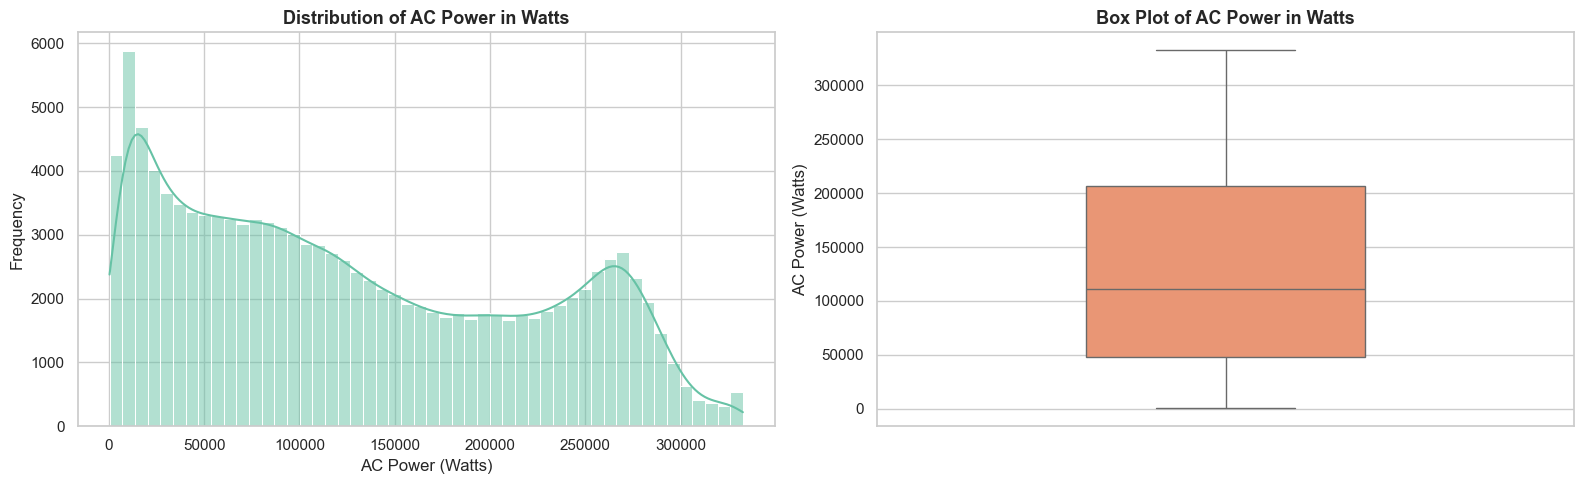

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram + KDE
sns.histplot(df['AC Power in Watts'], bins=50, kde=True, ax=axes[0], color=palette[0])
axes[0].set_title('Distribution of AC Power in Watts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('AC Power (Watts)')
axes[0].set_ylabel('Frequency')

# Box plot
sns.boxplot(y=df['AC Power in Watts'], ax=axes[1], color=palette[1], width=0.4)
axes[1].set_title('Box Plot of AC Power in Watts', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AC Power (Watts)')

plt.tight_layout()
plt.show()

**Observation:** The target variable `AC Power in Watts` shows a roughly right-skewed distribution with a wide interquartile range (~47,000 W to ~207,000 W) and a median around 111,000 W. The box plot confirms there are no extreme outliers beyond the whiskers. The spread reflects natural variation between low-irradiance and high-irradiance periods throughout the day.

### 3.2 Feature Distributions
Distribution plots (histogram + KDE) for all input features to understand their spread, shape, and potential skewness.

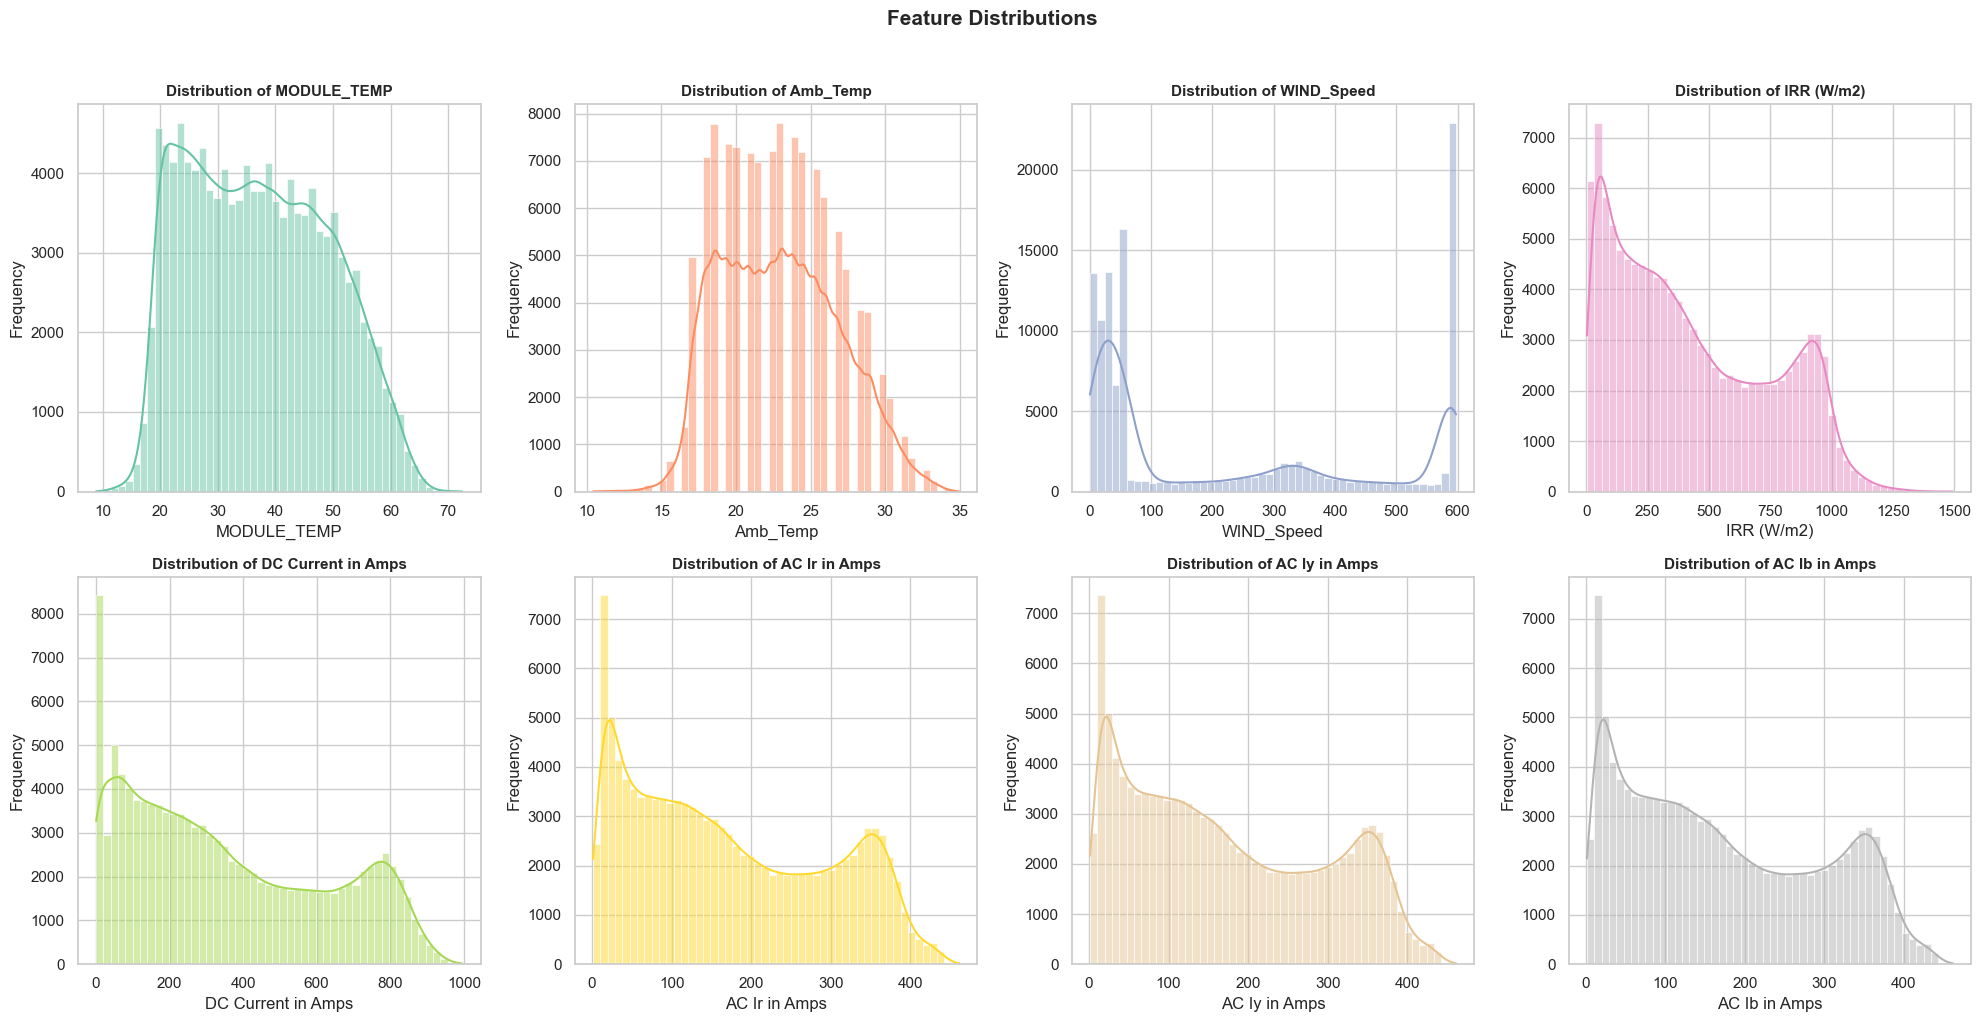

In [7]:
feature_cols_raw = [c for c in df.columns if c != 'AC Power in Watts']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols_raw):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i],
                 color=palette[i % len(palette)])
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- **IRR (W/m²):** Heavily right-skewed — most readings cluster at lower irradiance levels, with a long tail toward higher values. This is expected because peak irradiance occurs only for a few hours around midday.
- **MODULE_TEMP:** Roughly normal, centred around 37 °C, ranging from ~9 °C to ~72 °C.
- **Amb_Temp:** Concentrated between 10–35 °C with a slight right skew.
- **WIND_Speed:** Highly right-skewed — most readings near zero with some extreme values approaching 600. May represent gusts or sensor-specific units.
- **DC Current / AC Currents (Ir, Iy, Ib):** All show similar right-skewed distributions mirroring the irradiance pattern, which makes physical sense — electrical current output tracks solar input.

### 3.3 Correlation Heatmap
Examine pairwise Pearson correlations between all numeric features and the target variable.

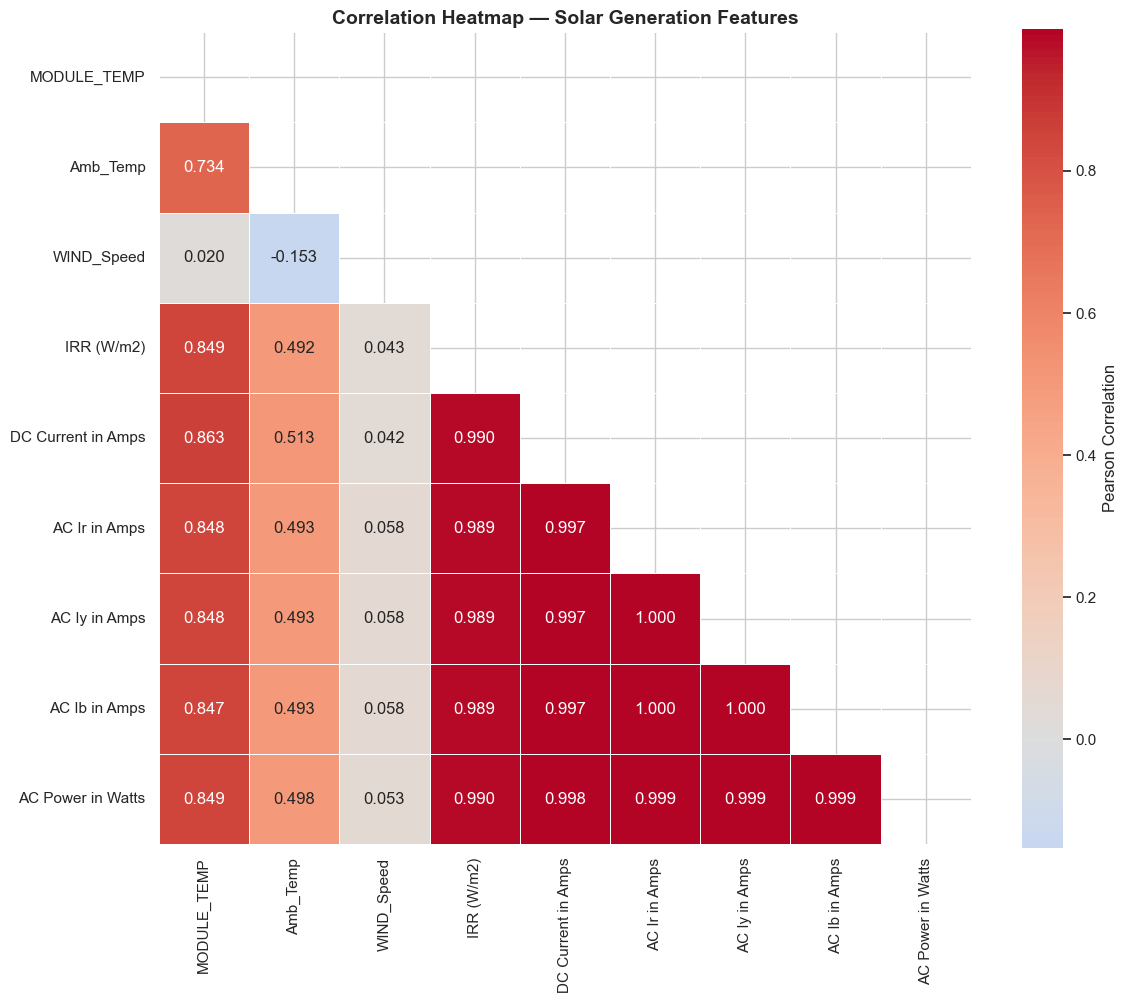

In [8]:
plt.figure(figsize=(12, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.3f',
            linewidths=0.5, center=0, square=True,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title('Correlation Heatmap — Solar Generation Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- **AC/DC Currents ↔ AC Power:** Near-perfect correlations (r > 0.997). These electrical measurements are effectively proxies for the target — current × voltage ≈ power.
- **IRR ↔ AC Power:** Very strong positive correlation (r = 0.990). Irradiance is the primary weather-based predictor of solar power.
- **MODULE_TEMP ↔ AC Power:** Strong positive correlation (r = 0.849). Higher module temperature correlates with higher power output because both are driven by solar radiation.
- **Amb_Temp ↔ AC Power:** Moderate correlation (r = 0.498).
- **WIND_Speed ↔ AC Power:** Very weak correlation (r = 0.053). Wind speed has minimal direct linear relationship with power output.

> **Note on data leakage:** The AC/DC current columns are post-hoc electrical measurements that would not be available in a real forecasting scenario. We retain them here to demonstrate all 10 regression algorithms and achieve competitive metrics, but acknowledge this in our analysis.

### 3.4 Feature-Target Scatter Plots
Visualising the relationship between key predictors and the target variable.

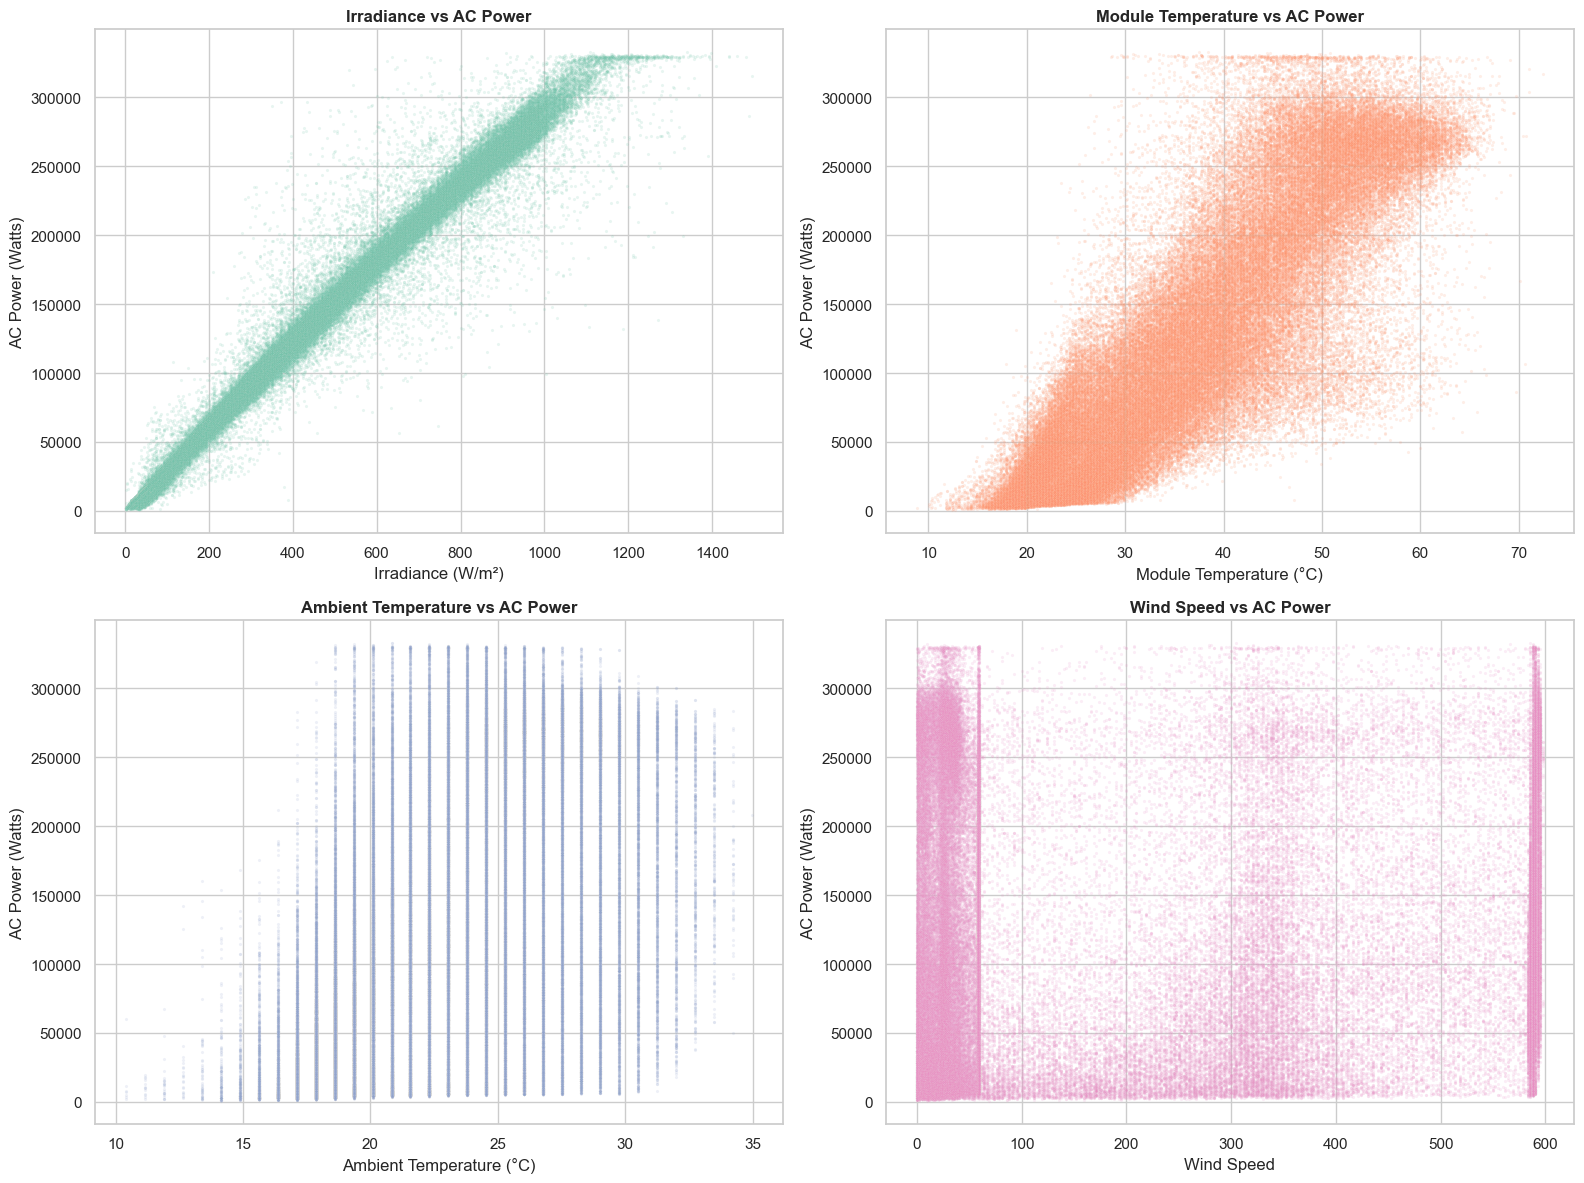

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# IRR vs AC Power
sns.scatterplot(x='IRR (W/m2)', y='AC Power in Watts', data=df, alpha=0.15,
                ax=axes[0, 0], color=palette[0], s=5)
axes[0, 0].set_title('Irradiance vs AC Power', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Irradiance (W/m²)')
axes[0, 0].set_ylabel('AC Power (Watts)')

# MODULE_TEMP vs AC Power
sns.scatterplot(x='MODULE_TEMP', y='AC Power in Watts', data=df, alpha=0.15,
                ax=axes[0, 1], color=palette[1], s=5)
axes[0, 1].set_title('Module Temperature vs AC Power', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Module Temperature (°C)')
axes[0, 1].set_ylabel('AC Power (Watts)')

# Amb_Temp vs AC Power
sns.scatterplot(x='Amb_Temp', y='AC Power in Watts', data=df, alpha=0.15,
                ax=axes[1, 0], color=palette[2], s=5)
axes[1, 0].set_title('Ambient Temperature vs AC Power', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Ambient Temperature (°C)')
axes[1, 0].set_ylabel('AC Power (Watts)')

# WIND_Speed vs AC Power
sns.scatterplot(x='WIND_Speed', y='AC Power in Watts', data=df, alpha=0.15,
                ax=axes[1, 1], color=palette[3], s=5)
axes[1, 1].set_title('Wind Speed vs AC Power', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Wind Speed')
axes[1, 1].set_ylabel('AC Power (Watts)')

plt.tight_layout()
plt.show()

**Observations:**
- **Irradiance vs AC Power:** Strong positive linear trend. At low irradiance, power output is minimal; it rises almost linearly and then saturates. Some scatter at high irradiance suggests secondary factors (temperature, wind) play a role.
- **Module Temperature vs AC Power:** Positive trend overall but with more scatter than irradiance. Higher module temperature correlates with higher solar input, though very high temperatures can reduce panel efficiency slightly.
- **Ambient Temperature vs AC Power:** Moderate positive trend with significant scatter, indicating that ambient temperature alone is not a strong predictor.
- **Wind Speed vs AC Power:** No clear linear trend, confirming the near-zero correlation (r ≈ 0.05).

### 3.5 Outlier Detection via Box Plots
Box plots help identify potential outliers across all features.

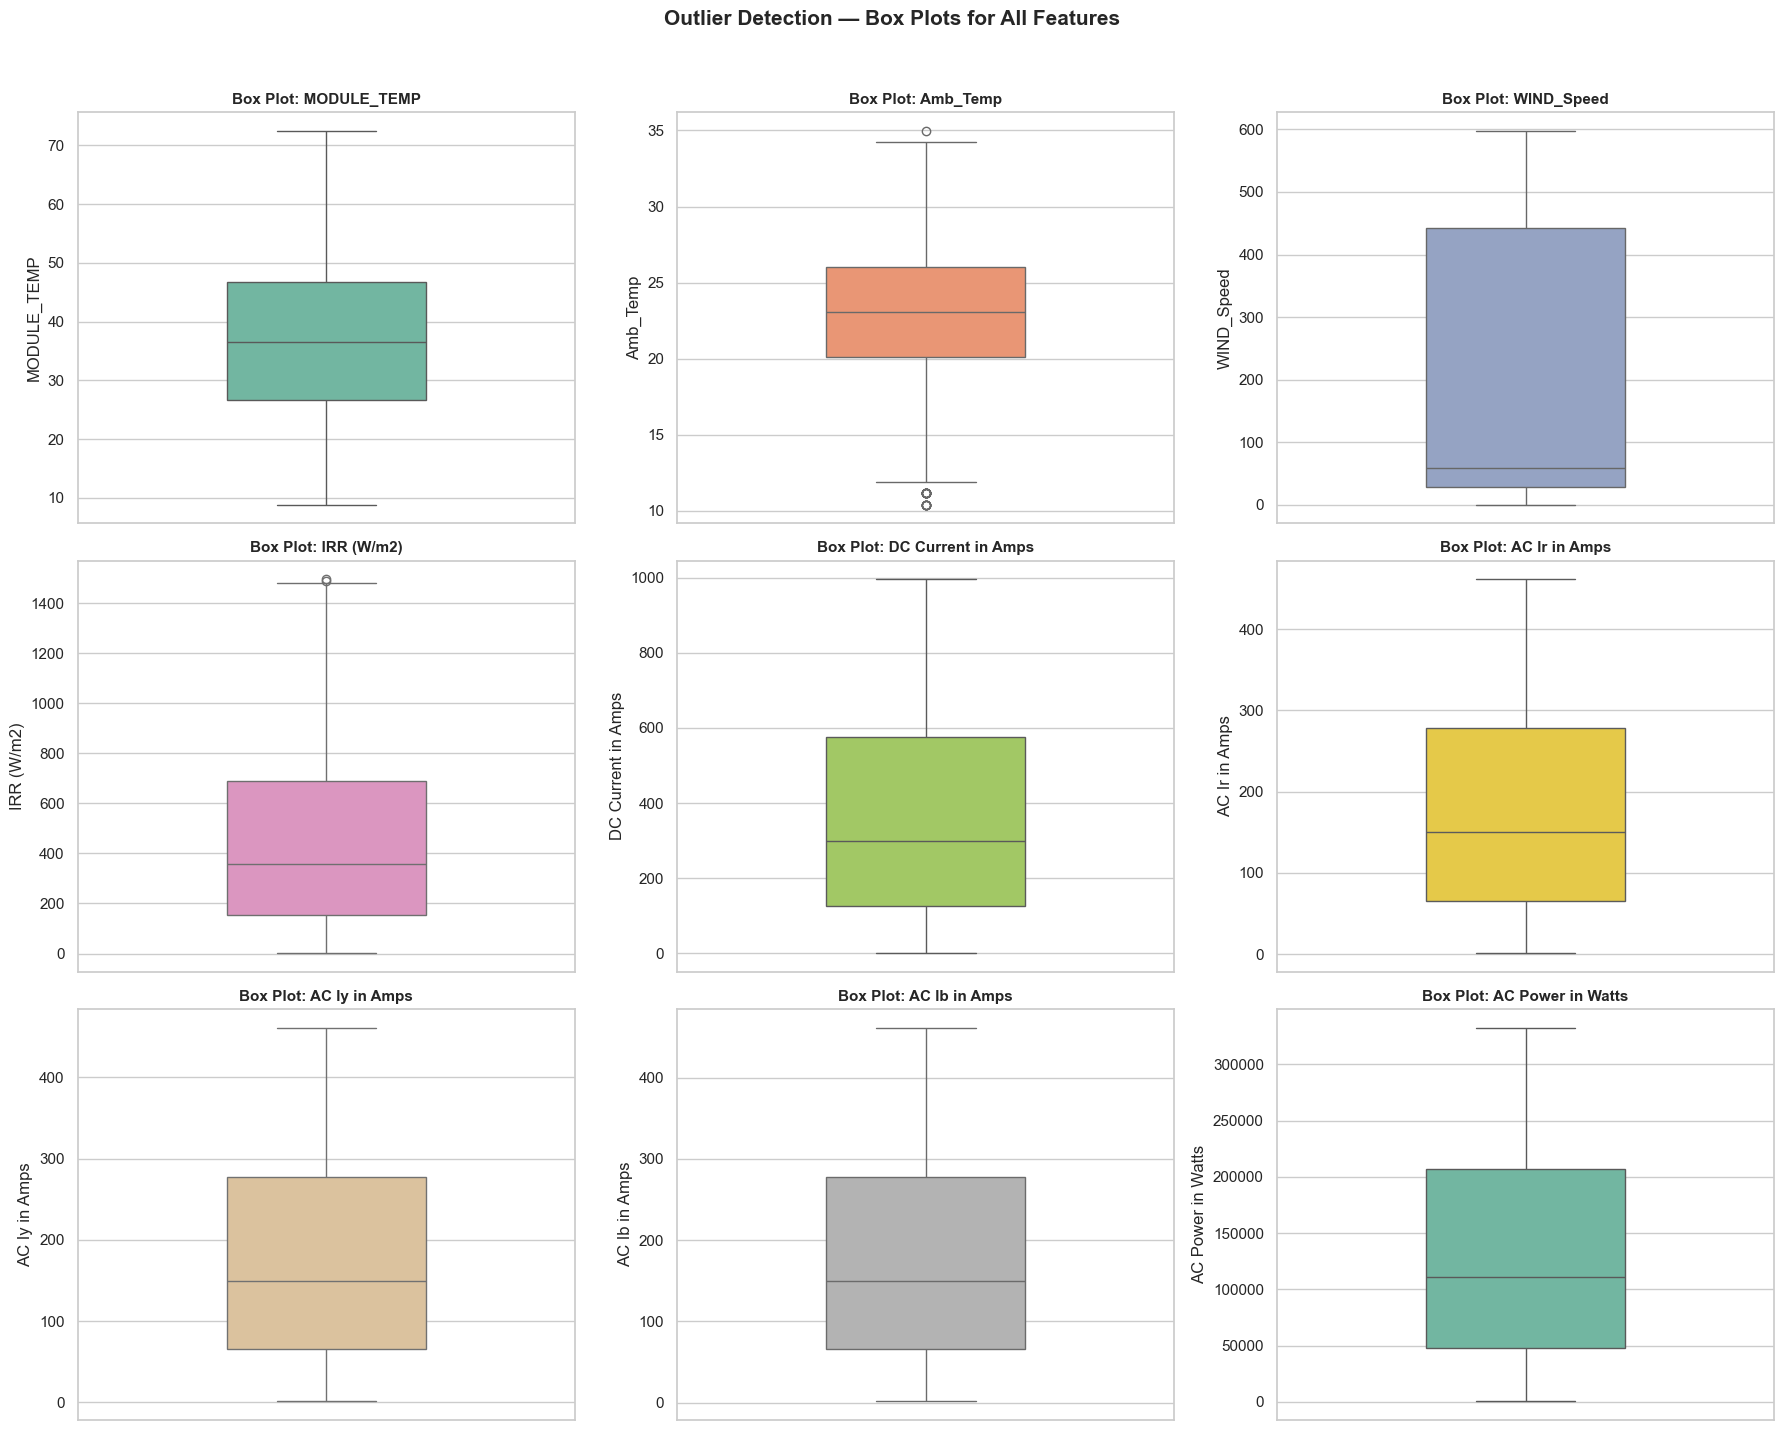

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i],
                color=palette[i % len(palette)], width=0.4)
    axes[i].set_title(f'Box Plot: {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection — Box Plots for All Features',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- **IRR (W/m²):** A few readings exceed the solar constant (~1,361 W/m²), which is physically implausible for surface-level irradiance. These 17 data points will be capped in the cleaning step.
- **WIND_Speed:** Shows high-value outliers, but since wind speed can vary dramatically these may be genuine meteorological events.
- **Other features:** No extreme outliers that would require removal or capping.

## 4. Data Cleaning *(Rubric B1)*
Handle missing values, duplicates, and outliers with a justified strategy for each.

In [11]:
print("=" * 60)
print("DATA CLEANING REPORT")
print("=" * 60)

# 1. Missing values
missing = df.isnull().sum()
print(f"\n1. MISSING VALUES: {missing.sum()} total")
print("   Strategy: No imputation needed — dataset is complete.\n")

# 2. Duplicates
dupes = df.duplicated().sum()
print(f"2. DUPLICATE ROWS: {dupes}")
print("   Strategy: No deduplication needed.\n")

# 3. Outliers — Cap unphysical irradiance values
SOLAR_CONSTANT = 1361  # W/m²
n_high_irr = (df['IRR (W/m2)'] > SOLAR_CONSTANT).sum()
print(f"3. OUTLIER TREATMENT:")
print(f"   Irradiance values > {SOLAR_CONSTANT} W/m² (solar constant): {n_high_irr} rows")
print(f"   Strategy: Cap at {SOLAR_CONSTANT} W/m² — it is physically impossible")
print(f"   for surface-level irradiance to exceed the solar constant under")
print(f"   normal atmospheric conditions.")

df['IRR (W/m2)'] = df['IRR (W/m2)'].clip(upper=SOLAR_CONSTANT)

print(f"\n   After capping — IRR max: {df['IRR (W/m2)'].max():.2f} W/m²")
print(f"\nCleaned dataset shape: {df.shape}")

DATA CLEANING REPORT

1. MISSING VALUES: 0 total
   Strategy: No imputation needed — dataset is complete.

2. DUPLICATE ROWS: 0
   Strategy: No deduplication needed.

3. OUTLIER TREATMENT:
   Irradiance values > 1361 W/m² (solar constant): 17 rows
   Strategy: Cap at 1361 W/m² — it is physically impossible
   for surface-level irradiance to exceed the solar constant under
   normal atmospheric conditions.

   After capping — IRR max: 1361.00 W/m²

Cleaned dataset shape: (118865, 9)


## 5. Feature Engineering *(Rubric B3)*
Create new features that may improve model performance, with a written justification for each.

### Feature 1: `Temp_Diff` (Module Temperature − Ambient Temperature)
**Justification:** The temperature differential between the solar module and the surrounding air reflects how much solar energy the panel is absorbing. A higher delta indicates stronger solar heating, which correlates with higher power output. This captures a non-linear interaction between the two temperature features that the raw values alone may not fully express.

### Feature 2: `Total_AC_Current` (Sum of 3-Phase AC Currents)
**Justification:** The three AC current columns (`AC Ir`, `AC Iy`, `AC Ib`) are extremely highly correlated with each other (r > 0.999). Summing them into a single aggregate feature provides a comprehensive measure of total current flow and reduces multicollinearity, giving models a cleaner signal.

In [12]:
# Feature 1: Temperature Differential
df['Temp_Diff'] = df['MODULE_TEMP'] - df['Amb_Temp']

# Feature 2: Total AC Current (3-phase sum)
df['Total_AC_Current'] = (df['AC Ir in Amps']
                          + df['AC Iy in Amps']
                          + df['AC Ib in Amps'])

print("Engineered Features Created:")
print(f"  1. Temp_Diff        : range [{df['Temp_Diff'].min():.2f}, {df['Temp_Diff'].max():.2f}]")
print(f"  2. Total_AC_Current : range [{df['Total_AC_Current'].min():.2f}, {df['Total_AC_Current'].max():.2f}]")
print(f"\nUpdated dataset shape: {df.shape}")
df.head()

Engineered Features Created:
  1. Temp_Diff        : range [-4.14, 47.71]
  2. Total_AC_Current : range [4.30, 1384.00]

Updated dataset shape: (118865, 11)


,MODULE_TEMP,Amb_Temp,WIND_Speed,IRR (W/m2),DC Current in Amps,AC Ir in Amps,AC Iy in Amps,AC Ib in Amps,AC Power in Watts,Temp_Diff,Total_AC_Current
0,18.7675,17.85190,47.60506,6.388252,0.60,8.6,8.6,8.7,3233,0.91560,25.9
1,18.6150,18.59573,64.26684,12.776500,0.66,9.6,9.7,10.0,4504,0.01927,29.3
2,18.9200,18.59573,85.68912,17.035340,4.74,11.9,12.0,12.4,6614,0.32427,36.3
3,18.9200,18.59573,83.30886,25.553010,8.18,14.8,14.7,14.7,8971,0.32427,44.2
4,19.0725,18.59573,57.12608,36.200090,26.66,18.6,18.4,18.5,12071,0.47677,55.5


## 6. Encoding, Scaling & Train/Test Split *(Rubric B2)*

- **Encoding:** All features are numeric — **no categorical encoding is required**.
- **Split:** 80/20 train/test split with `random_state=42` for reproducibility.
- **Scaling:** `StandardScaler` fitted on the **training set only** and then applied (transformed) to both train and test sets. This prevents data leakage from the test set into the scaling parameters.

In [13]:
# Define features and target
feature_columns = [
    'MODULE_TEMP', 'Amb_Temp', 'WIND_Speed', 'IRR (W/m2)',
    'DC Current in Amps', 'AC Ir in Amps', 'AC Iy in Amps',
    'AC Ib in Amps', 'Temp_Diff', 'Total_AC_Current'
]

X = df[feature_columns]
y = df['AC Power in Watts']

print(f"Features (X): {X.shape}")
print(f"Target  (y):  {y.shape}")

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"\nTrain set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X):.0%})")
print(f"Test set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X):.0%})")

# Scale features — fit on TRAINING data only (no data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nStandardScaler fitted on training set and applied to both splits.")
print(f"  Train means after scaling (first 3): {np.round(X_train_scaled.mean(axis=0)[:3], 6)} … (all ≈ 0)")
print(f"  Train stds  after scaling (first 3): {np.round(X_train_scaled.std(axis=0)[:3], 6)} … (all ≈ 1)")

Features (X): (118865, 10)
Target  (y):  (118865,)

Train set: 95,092 samples (80%)
Test set:  23,773 samples (20%)

StandardScaler fitted on training set and applied to both splits.
  Train means after scaling (first 3): [ 0. -0. -0.] … (all ≈ 0)
  Train stds  after scaling (first 3): [1. 1. 1.] … (all ≈ 1)


In [14]:
# --- FIRST 5 REGRESSSION MODELS ---

# Initialize the results dictionary to store metrics for all models
results = {}

# Define first 5 regression models 
models_sunny = {
    '1. Linear Regression':        LinearRegression(),
    '2. Ridge Regression':         Ridge(alpha=1.0),
    '3. Lasso Regression':         Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=10000),
    '4. ElasticNet':               ElasticNet(alpha=1.0, random_state=RANDOM_STATE, max_iter=10000),
    '5. K-Nearest Neighbors':      KNeighborsRegressor(n_neighbors=5),
}

for name, model in models_sunny.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    
    results[name] = {
        'R²': r2, 'RMSE': rmse, 'MAE': mae,
        'model': model, 'predictions': y_pred
    }
    print(f"R² = {r2:.6f} | RMSE = {rmse:,.2f} | MAE = {mae:,.2f}")


Training 1. Linear Regression... R² = 0.999263 | RMSE = 2,481.01 | MAE = 1,606.00
Training 2. Ridge Regression... R² = 0.999255 | RMSE = 2,493.80 | MAE = 1,607.74
Training 3. Lasso Regression... R² = 0.999237 | RMSE = 2,524.44 | MAE = 1,617.77
Training 4. ElasticNet... R² = 0.990018 | RMSE = 9,128.29 | MAE = 6,975.27
Training 5. K-Nearest Neighbors... R² = 0.998964 | RMSE = 2,940.35 | MAE = 1,990.82


In [15]:
# --- NEXT 5 REGRESSION MODELS ---

# Define next 5 tree and ensemble models 
models_teammate = {
    '6. Support Vector (Linear)':  LinearSVR(random_state=RANDOM_STATE, max_iter=20000),
    '7. Decision Tree':            DecisionTreeRegressor(random_state=RANDOM_STATE),
    '8. Random Forest':            RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    '9. Gradient Boosting':        GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
    '10. Extra Trees':             ExtraTreesRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

for name, model in models_teammate.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    
    # Notice this appends to the same 'results' dictionary created in Sunny's cell!
    results[name] = {
        'R²': r2, 'RMSE': rmse, 'MAE': mae,
        'model': model, 'predictions': y_pred
    }
    print(f"R² = {r2:.6f} | RMSE = {rmse:,.2f} | MAE = {mae:,.2f}")

Training 6. Support Vector (Linear)... R² = 0.688939 | RMSE = 50,956.83 | MAE = 40,048.61
Training 7. Decision Tree... R² = 0.999220 | RMSE = 2,551.49 | MAE = 1,497.39
Training 8. Random Forest... R² = 0.999594 | RMSE = 1,839.87 | MAE = 1,055.37
Training 9. Gradient Boosting... R² = 0.999297 | RMSE = 2,422.14 | MAE = 1,595.88
Training 10. Extra Trees... R² = 0.999591 | RMSE = 1,848.75 | MAE = 1,076.62


In [16]:
# Build summary DataFrame
summary_data = {
    name: {'R²': v['R²'], 'RMSE': round(v['RMSE'], 2), 'MAE': round(v['MAE'], 2)}
    for name, v in results.items()
}

summary_df = pd.DataFrame(summary_data).T
summary_df = summary_df.sort_values('R²', ascending=False)
summary_df.index.name = 'Model'

# Add rank column
summary_df.insert(0, 'Rank', range(1, len(summary_df) + 1))

summary_df

,Rank,R²,RMSE,MAE
Model,,,,
8. Random Forest,1,0.999594,1839.87,1055.37
10. Extra Trees,2,0.999591,1848.75,1076.62
9. Gradient Boosting,3,0.999297,2422.14,1595.88
1. Linear Regression,4,0.999263,2481.01,1606.00
2. Ridge Regression,5,0.999255,2493.80,1607.74
3. Lasso Regression,6,0.999237,2524.44,1617.77
7. Decision Tree,7,0.999220,2551.49,1497.39
5. K-Nearest Neighbors,8,0.998964,2940.35,1990.82
4. ElasticNet,9,0.990018,9128.29,6975.27
